# Does history depth affect how well the model predicts?

The tuned CatBoost model (Prompt 14) scores test PR-AUC 0.174 overall. This notebook doesn't change the model, it asks whether that score is roughly the same for every establishment or whether it's better or worse depending on how much pre-2023 inspection history an establishment had before the modern target period began. No new model is trained beyond the one fixed tuned CatBoost, and the full test set stays intact, this is subgroup diagnosis, not a way to pick a "better" test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix)

CUTOFF = pd.Timestamp("2023-11-10")

pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
print("prediction rows:", len(pred))

prediction rows: 69766


## Rebuild the 15-feature set (same as Prompt 11/14, no changes)

In [2]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_window(g, days, prefix):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(days, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        f"{prefix}_n_inspections": idx_arr - low_idx,
        f"{prefix}_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        f"{prefix}_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        f"{prefix}_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled_730 = long.groupby("estId", group_keys=False).apply(rolling_window, days=730, prefix="prior_730d").set_index("orig_index")
long_feat = long.join(rolled_730)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)

BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES = BASE + HIST365 + HIST730
assert len(FEATURES) == 15

## Recreate the exact strict split and test set

In [3]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

assert len(train) == 45334
assert len(test) == 12692
assert test["inspectionDate"].min() == pd.Timestamp("2026-04-10")
assert test["inspectionDate"].max() == pd.Timestamp("2026-09-08")
print("test set: 12,692 rows,", test["inspectionDate"].min().date(), "to", test["inspectionDate"].max().date())

test set: 12,692 rows, 2026-04-10 to 2026-09-08


## Train the fixed tuned CatBoost model

Exact same configuration selected in Prompt 14, trained on the training partition only.

In [4]:
X_train, y_train = train[FEATURES], train["target"]
X_test, y_test = test[FEATURES], test["target"]

model = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
)
model.fit(X_train, y_train)
print("trained")

trained


## Reproduce the overall test metrics

Just to confirm this is the same model/test setup as Prompt 14, not a replacement for that result.

In [5]:
test_proba = model.predict_proba(X_test)[:, 1]
THRESHOLD = 0.70
test_pred = (test_proba >= THRESHOLD).astype(int)

print("test PR-AUC:", round(average_precision_score(y_test, test_proba), 4), "(expect ~0.174)")
print("test ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4), "(expect ~0.734)")
print("test precision:", round(precision_score(y_test, test_pred, zero_division=0), 4))
print("test recall:", round(recall_score(y_test, test_pred, zero_division=0), 4))
print("test f1:", round(f1_score(y_test, test_pred, zero_division=0), 4))
print("test accuracy:", round(accuracy_score(y_test, test_pred), 4))

test PR-AUC: 0.1742 (expect ~0.174)
test ROC-AUC: 0.7337 (expect ~0.734)
test precision: 0.2098
test recall: 0.3019
test f1: 0.2475
test accuracy: 0.862


## Pre-cutoff history depth

For each establishment, count inspections strictly before 2023-11-10 in the longitudinal table, this is fixed information available before the whole modern target period began, not something that changes across an establishment's different target dates. Used for grouping only, never passed to the model.

In [6]:
pre_cutoff_counts = long[long["inspectionDate"] < CUTOFF].groupby("estId").size()

test = test.copy()
test["pre_cutoff_inspections"] = test["estId"].map(pre_cutoff_counts).fillna(0).astype(int)
test["test_proba"] = test_proba
test["test_pred"] = test_pred

assert "pre_cutoff_inspections" not in FEATURES
assert "history_group" not in FEATURES

def group_label(n):
    if n == 0:
        return "no_history"
    elif n <= 4:
        return "1_to_4_history"
    else:
        return "5_plus_history"

test["history_group"] = test["pre_cutoff_inspections"].apply(group_label)
test["history_group"].value_counts()

history_group
5_plus_history    5969
no_history        4532
1_to_4_history    2191
Name: count, dtype: int64

## Stratified evaluation

Same fixed threshold (0.70) used for every group, no per-group threshold selection, so the groups stay directly comparable.

In [7]:
rows = []
for grp in ["no_history", "1_to_4_history", "5_plus_history"]:
    sub = test[test["history_group"] == grp]
    y_sub = sub["target"]
    proba_sub = sub["test_proba"]
    pred_sub = sub["test_pred"]
    rows.append({
        "history_group": grp,
        "test_rows": len(sub),
        "establishments": sub["estId"].nunique(),
        "non_pass_prevalence": y_sub.mean(),
        "pr_auc": average_precision_score(y_sub, proba_sub),
        "roc_auc": roc_auc_score(y_sub, proba_sub),
        "precision": precision_score(y_sub, pred_sub, zero_division=0),
        "recall": recall_score(y_sub, pred_sub, zero_division=0),
        "f1": f1_score(y_sub, pred_sub, zero_division=0),
    })

result_df = pd.DataFrame(rows)
result_df

,history_group,test_rows,establishments,non_pass_prevalence,pr_auc,roc_auc,precision,recall,f1
0,no_history,4532,3730,0.085834,0.175144,0.720790,0.185328,0.246787,0.211687
1,1_to_4_history,2191,1775,0.075308,0.204357,0.756865,0.251082,0.351515,0.292929
2,5_plus_history,5969,4856,0.067013,0.166292,0.732855,0.214744,0.335000,0.261719


In [8]:
assert result_df["test_rows"].sum() == len(test) == 12692
print("subgroup rows sum to the full test set:", result_df["test_rows"].sum())

subgroup rows sum to the full test set: 12692


No history performs worst on PR-AUC and ROC-AUC (0.175, 0.721) despite having the highest Non-Pass prevalence (8.6%) of the three groups. The 1-4-history group is actually the strongest (PR-AUC 0.204, ROC-AUC 0.757), better than both no-history and 5+-history. The 5+-history group, despite having the most historical information available, scores the lowest PR-AUC of all three (0.166), though its ROC-AUC (0.733) is close to the overall average.

This is not a simple "more history is better" story. It's closer to a middle-group advantage: some history helps a lot over none, but having a very long track record doesn't keep helping and even coincides with the lowest PR-AUC here, possibly because well-established, heavily-inspected establishments have a lower and less variable Non-Pass rate (6.7% vs 8.6% for no-history), which is intrinsically harder to rank well on a precision-recall basis. This is an observation about this fixed model on this test set, not a general law about the problem.

## Optional exact-count breakdown

Checking whether the grouping choice is hiding something inside the 1-4 bucket specifically, only where each count has enough rows to be worth reporting.

In [9]:
for n in range(5):
    sub = test[test["pre_cutoff_inspections"] == n]
    if len(sub) > 0:
        print(f"pre_cutoff_inspections={n}: rows={len(sub)}, prevalence={round(sub['target'].mean(), 4)}")

sub5plus = test[test["pre_cutoff_inspections"] >= 5]
print(f"pre_cutoff_inspections>=5: rows={len(sub5plus)}, prevalence={round(sub5plus['target'].mean(), 4)}")

pre_cutoff_inspections=0: rows=4532, prevalence=0.0858
pre_cutoff_inspections=1: rows=473, prevalence=0.0698
pre_cutoff_inspections=2: rows=527, prevalence=0.0588
pre_cutoff_inspections=3: rows=610, prevalence=0.0754
pre_cutoff_inspections=4: rows=581, prevalence=0.0947
pre_cutoff_inspections>=5: rows=5969, prevalence=0.067


All five exact counts (0-4) have several hundred rows each, enough to be informative rather than noise-driven. Prevalence bounces around within the 1-4 range (7.0% to 9.5%) without a clear monotonic pattern, so the 1-4 group's strong PR-AUC doesn't look like it's being driven by one single count value dominating the bucket.

## Save results

In [10]:
result_df.to_csv("../outputs/history_depth_test_results.csv", index=False)
print("saved outputs/history_depth_test_results.csv")

saved outputs/history_depth_test_results.csv


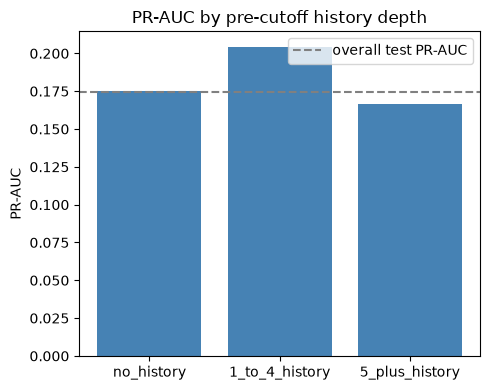

In [11]:
plt.figure(figsize=(5, 4))
plt.bar(result_df["history_group"], result_df["pr_auc"], color="steelblue")
plt.axhline(average_precision_score(y_test, test_proba), linestyle="--", color="gray", label="overall test PR-AUC")
plt.ylabel("PR-AUC")
plt.title("PR-AUC by pre-cutoff history depth")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/history_depth_pr_auc.png", dpi=100)
plt.show()

## Leakage / validity checks

In [12]:
assert test["inspectionDate"].min() == pd.Timestamp("2026-04-10")
assert test["inspectionDate"].max() == pd.Timestamp("2026-09-08")
assert len(test) == 12692
assert "history_group" not in FEATURES
assert "pre_cutoff_inspections" not in FEATURES
assert (long[long["inspectionDate"] < CUTOFF]["inspectionDate"] < CUTOFF).all()
assert result_df["test_rows"].sum() == 12692
print("all checks passed")

all checks passed


## Interpretation

Performance does depend on historical depth, but not in a simple monotonic way. No-history establishments are predicted worst on the ranking metrics despite having the highest observed Non-Pass rate, and the group with a long track record (5+) doesn't do better than the group with a modest one (1-4), it actually scores the lowest PR-AUC of the three. So the earlier aggregate PR-AUC of 0.174 isn't a case of "the model works well for established establishments, dragged down by cold-start cases", the picture is more mixed: cold-start cases are indeed harder, but more history doesn't keep helping past a modest amount, at least for this fixed model on this feature set.

This points toward the current predictive limitation being fairly general rather than concentrated purely in cold-start establishments, richer historical depth alone (beyond a handful of inspections) does not appear to be the main lever left to pull.